Epoch 1, Loss: 1.004


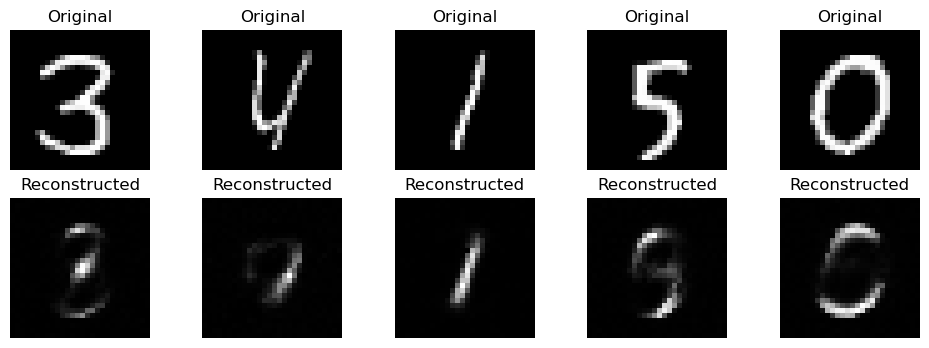

Epoch 2, Loss: 0.897


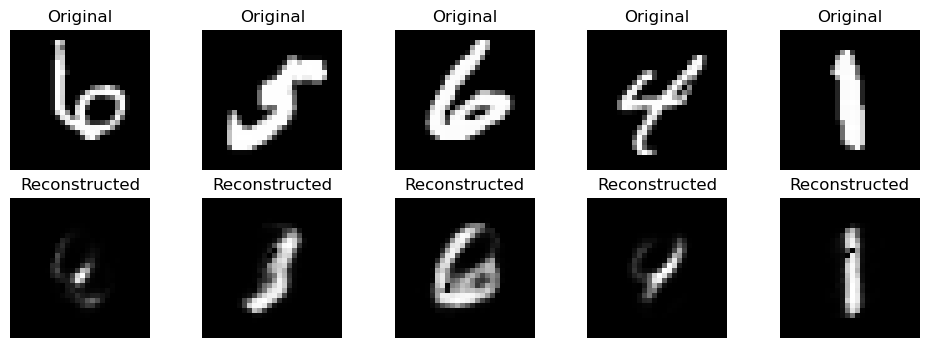

Epoch 3, Loss: 0.882


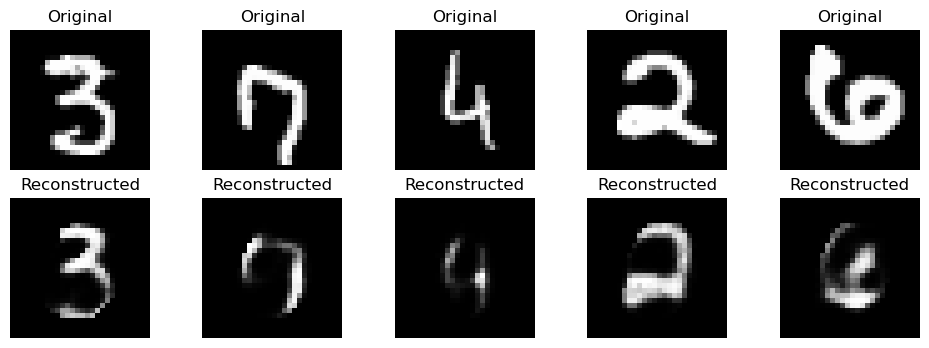

KeyboardInterrupt: 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Define the autoencoder model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.encoder(x)
        x = x.view(-1, 128)
        x = self.decoder(x)
        x = x.view(-1, 1, 28, 28)
        return x

# Initialize the autoencoder and move it to the GPU (if available)
autoencoder = Autoencoder().to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.0001)

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in train_loader:
        inputs, _ = data
        inputs = inputs.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = autoencoder(inputs)
        loss = criterion(outputs, inputs)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_loader):.3f}')
    running_loss = 0.0

    # Display 5 examples of original and reconstructed images
    with torch.no_grad():
        dataiter = iter(train_loader)
        images, _ = dataiter.next()
        images = images.to(device)
        outputs = autoencoder(images)
        images = images.cpu()
        outputs = outputs.cpu()

        fig, axes = plt.subplots(2, 5, figsize=(12, 4))
        for i in range(5):
            axes[0, i].imshow(images[i].view(28, 28), cmap='gray')
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')
            axes[1, i].imshow(outputs[i].view(28, 28), cmap='gray')
            axes[1, i].set_title('Reconstructed')
            axes[1, i].axis('off')
        plt.show()

print('Finished Training Autoencoder')